### Scripts to compare mHM and Wetspass-M simulated recharge

In [1]:
import xarray as xr
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import mhm_dataprocessing as md

#segoe ui font
plt.rcParams['font.family'] = 'Segoe UI'

In [3]:
src_dir_wetspass = r"W:/VUB/_main_research/data/recharge_zainab/recharge/recharge_y"
src_dir_mHM = r"D:/VUB/_data/EOBS_mHM_output"
vl_shp = gpd.read_file(r"W:/VUB/Proposal/geospatial data/Vlaanderen.shp")

#wetspass recharge
wetspass_nc = xr.open_dataset(f"{src_dir_wetspass}/annual_recharge_VL.nc")
wetspass_coarse = xr.open_dataset(f"{src_dir_wetspass}/wetspass_coarse.nc")
#rename Band1 to recharge in wetspass
wetspass_nc = wetspass_nc.rename({"Band1": "recharge"})
#rename long_name and units for mHM
wetspass_nc['recharge'].attrs['long_name'] = 'Annual Recharge (mm)'
wetspass_nc = wetspass_nc.where(wetspass_nc.recharge >= -20, drop=True)


#mHM to compute recharge similar to wetspass
#In wetspass recharge is computed as precipitation - evapotranspiration - runoff. We follow the same approach for mHM
#open mhm containing aET+ Q
mhm_efflux = xr.open_dataset(f"{src_dir_mHM}/efflux_w.nc")
mhm_EOBS = xr.open_dataset(f"{src_dir_mHM}/mHM_recharge_BE.nc")

#open mhm precipitation
mhm_precip = xr.open_dataset(f"{src_dir_mHM}/pre_remap_L1.nc")
#clip to flanders
mhm_efflux_vl = md.clip_to_region(vl_shp, mhm_efflux, epsg_code='epsg:4326')
mhm_precip_vl = md.clip_to_region(vl_shp, mhm_precip, epsg_code='epsg:4326')
mhm_EOBS_vl = md.clip_to_region(vl_shp, mhm_EOBS, epsg_code='epsg:4326')

#### Resample mHM recharge to annual

In [4]:
# mask where variance is zero (keep)
mhm_efflux_mask = mhm_efflux_vl.where(mhm_efflux_vl['efflux'].var(dim='time') > 0.001)

# If datasets are already monthly at month-start, this will just keep them aligned.
# If they are daily/hourly, this aggregates to monthly totals labeled on month-start.

min_year = '1980-01-01'
max_year = '1995-12-31'

mhm_efflux_monthly = mhm_efflux_mask.sel(time=slice(min_year, max_year)).resample(time='ME').mean()   # <-- changed ME->MS and mean->sum
mhm_precip_monthly = mhm_precip_vl.sel(time=slice(min_year, max_year)).resample(time='ME').sum()    # <-- changed ME->MS (sum stays)
mhm_EOBS_monthly = mhm_EOBS_vl.sel(time=slice(min_year, max_year)).resample(time='ME').mean()    # <-- changed ME->MS and mean->sum


# Compute recharge/residual
mhm_precip_monthly, mhm_efflux_monthly = xr.align(
    mhm_precip_monthly, mhm_efflux_monthly, join="inner"
)
mhm_residual_mon = mhm_precip_monthly['pre'] - mhm_efflux_monthly['efflux']

#to xr.Dataset
mhm_residual_mon = mhm_residual_mon.to_dataset(name='residual')


# Annual totals (year-end labels)
mhm_res_annual = mhm_residual_mon.resample(time='YE').sum() 
mhm_EOBS_annual = mhm_EOBS_monthly.resample(time='YE').sum()  

#Mean over years
mhm_y = mhm_res_annual.mean(dim='time')
mhm_EOBS_y = mhm_EOBS_annual.mean(dim='time')
mhm_valid = mhm_y.where((mhm_y['residual'] > 0) & (mhm_y['residual'] < 500), drop=True)
wetspass_land = wetspass_coarse.where((wetspass_coarse['recharge'] > 50), drop=True)

#mask wetspass to mHM valid area
wetspass_masked = wetspass_coarse.where(~np.isnan(mhm_valid['residual']), drop=True)
wetspass_valid = wetspass_land['recharge'].where((~np.isnan(mhm_valid['residual'])) , drop=True)

mHM Recharge mean: 241.90866
Wetspass Recharge mean: 233.78725


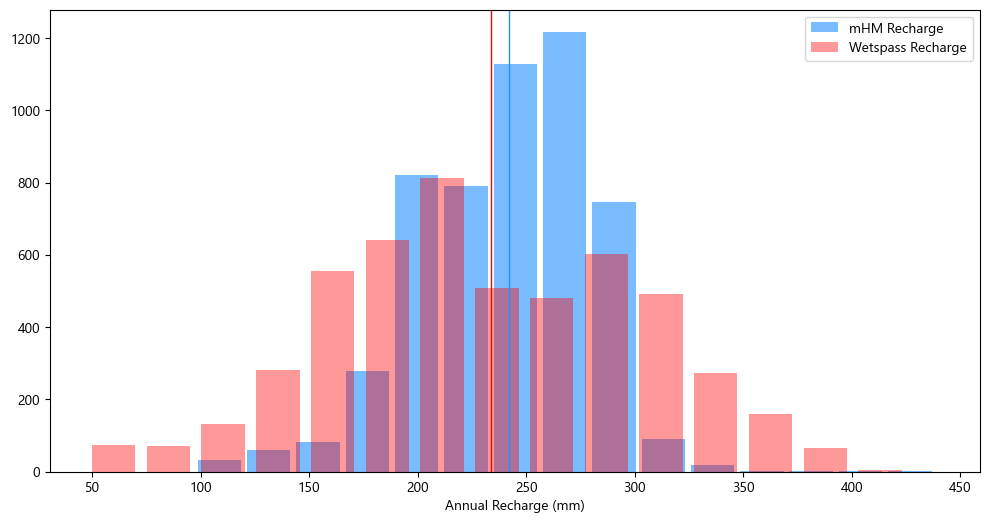

In [4]:
##plot comparison histograms
plt.figure(figsize=(12,6))
plt.hist(mhm_valid['residual'].values.flatten(), bins=15, alpha=0.6, label='mHM Recharge', color='dodgerblue',  width=20)
plt.hist(wetspass_valid.values.flatten(), bins=15, alpha=0.4, label='Wetspass Recharge', color='red', width=20)
plt.axvline(np.nanmean(mhm_valid['residual'].values), color='dodgerblue', linewidth=1)
plt.axvline(np.nanmean(wetspass_valid.values), color='red', linewidth=1)
plt.xlabel('Annual Recharge (mm)')
plt.legend()

print("mHM Recharge mean:", np.nanmean(mhm_valid['residual'].values))
print("Wetspass Recharge mean:", np.nanmean(wetspass_valid.values))

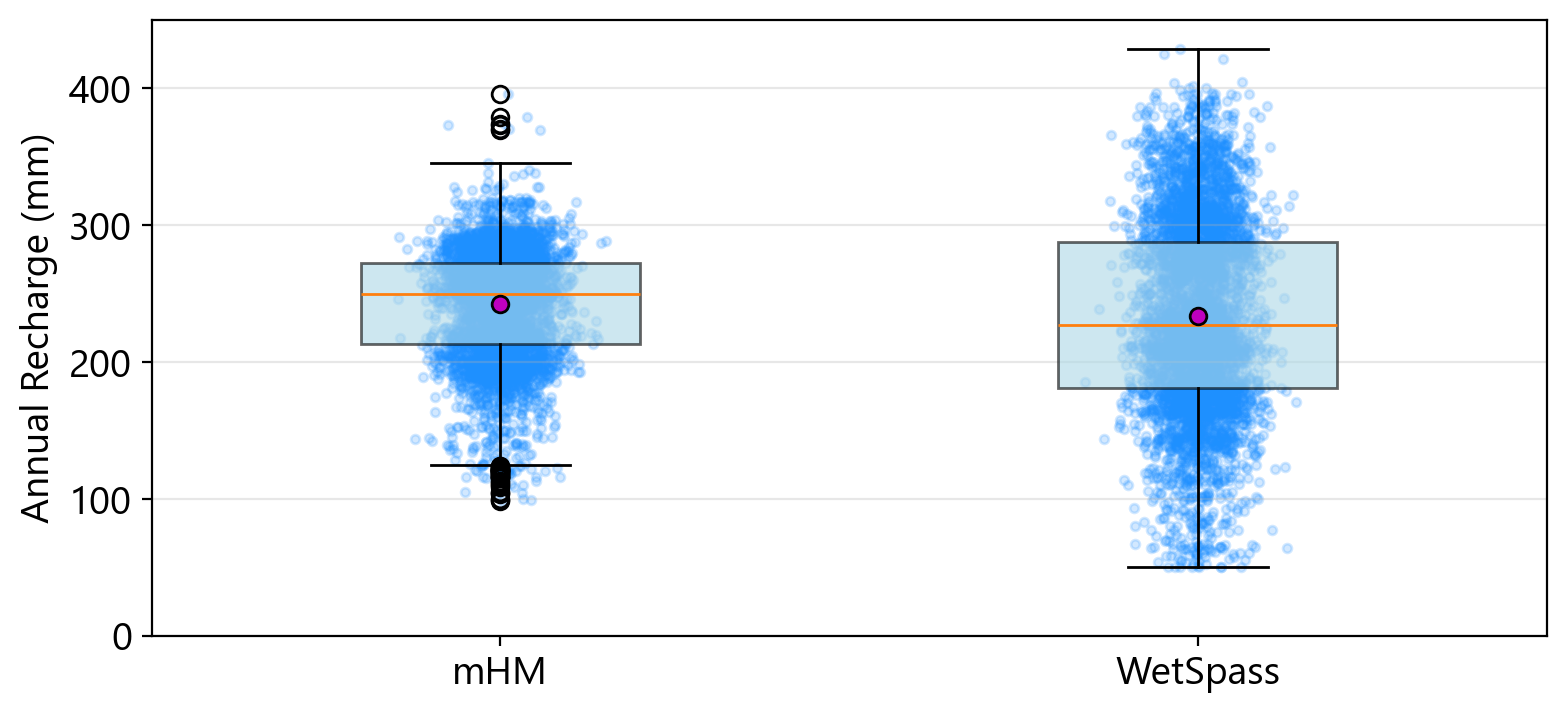

In [5]:
# -------------------------
# 0) Prepare paired samples
# -------------------------
mhm = mhm_valid['residual'].values.ravel()
wet = wetspass_valid.values.ravel() 

# keep only paired finite values (same pixels)
mask = np.isfinite(mhm) & np.isfinite(wet)
mhm_p = mhm[mask]
wet_p = wet[mask] 
# wet_p = wet_p[wet_p > 50]  #remove extreme values

# -------------------------
# 2) Overlaid histograms
# -------------------------
# plt.figure(figsize=(12,6))
# plt.hist(mhm_p, bins=15, alpha=0.6, label='mHM Recharge')
# plt.hist(wet_p, bins=15, alpha=0.4, label='WetSpass Recharge')
# plt.axvline(mhm_p.mean(), linewidth=1)
# plt.axvline(wet_p.mean(), linewidth=1)
# plt.xlabel('Annual Recharge (mm)')
# plt.ylabel('Count')
# plt.title('Overlaid histograms')
# plt.legend()
# plt.show()


# -------------------------
# 9) Boxplot + violin (side-by-side distribution summary)
# -------------------------
data = [mhm_p, wet_p]
labels = ["mHM", "WetSpass"]

plt.figure(figsize=(9,4), dpi=200)
parts = plt.boxplot(data, showmeans=True, meanprops={"marker":"o","markerfacecolor":"m", "markeredgecolor":"black"},
                     widths=0.4, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.6))
#
plt.xticks([1, 2], labels, fontsize=14)
plt.yticks(fontsize=14)
#ytick intervals
plt.ylim(0, 450)
plt.yticks(np.arange(0, 451, 100))

plt.ylabel("Annual Recharge (mm)", fontsize=14)
plt.grid(True, axis='y', alpha=0.3)
#add scatter of individual points
for i in range(len(data)):
    y = data[i]
    x = np.random.normal(i + 1, 0.04, size=len(y))  # add some random "jitter" to the x-axis
    plt.scatter(x, y, alpha=0.2, color='dodgerblue', s=10)

plt.show()

#### Plot maps of long-term annual recharge

In [20]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_recharge_side_by_side(
    mhm_da, wet_da, vl_shp,
    titles=("mHM internal recharge flux", "WetSpass recharge"),
    panel_labels=("", ""),
    cmap="YlGnBu",
    dpi=150
):
    """
    Plot two recharge rasters side-by-side with separate color limits and separate colorbars.
    Adds Vlaanderen boundary from vl_shp. Uses Cartopy PlateCarree.
    """

    # Ensure Vlaanderen shapefile is lon/lat
    vl_4326 = vl_shp.to_crs(epsg=4326)

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        1, 2, figsize=(12, 8),
        subplot_kw={"projection": proj},
        dpi=dpi
    )

    # ---- common extent from Vlaanderen bounds ----
    minx, miny, maxx, maxy = vl_4326.total_bounds
    padx = (maxx - minx) * 0.05
    pady = (maxy - miny) * 0.05
    extent = [minx - padx, maxx + padx, miny - pady, maxy + pady]

    # Helper to get robust vmin/vmax per dataset (optional: use percentiles)
    def get_limits(da):
        # percentiles
        vmin = 100
        vmax = float(da.quantile(0.95).values)
        if vmin == vmax:
            vmin -= 1e-6
            vmax += 1e-6
        return vmin, vmax

    # ---- panel A: mHM ----
    ax0 = axes[0]
    ax0.set_extent(extent, crs=proj)

    vmin0, vmax0 = get_limits(mhm_da)
    im0 = mhm_da.plot(
        ax=ax0, transform=proj,
        cmap=cmap, vmin=vmin0, vmax=vmax0,
        add_colorbar=False
    )
    vl_4326.boundary.plot(ax=ax0, transform=proj, color="black", linewidth=0.6, zorder=5)
    ax0.coastlines(resolution="10m", linewidth=0.5)
    ax0.set_title(titles[0], fontsize=16)
    ax0.text(
        0.02, 0.98, panel_labels[0], transform=ax0.transAxes,
        va="top", ha="left", fontsize=13,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
    )

    # ---- panel B: WetSpass ----
    ax1 = axes[1]
    ax1.set_extent(extent, crs=proj)

    vmin1, vmax1 = get_limits(wet_da)
    im1 = wet_da.plot(
        ax=ax1, transform=proj,
        cmap=cmap, vmin=vmin1, vmax=vmax1,
        add_colorbar=False
    )
    vl_4326.boundary.plot(ax=ax1, transform=proj, color="black", linewidth=0.6, zorder=5)
    ax1.coastlines(resolution="10m", linewidth=0.5)
    ax1.set_title(titles[1], fontsize=14)
    ax1.text(
        0.02, 0.98, panel_labels[1], transform=ax1.transAxes,
        va="top", ha="left", fontsize=13,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)
    )

    # ---- separate colorbars (one under each panel) ----
    # Make explicit cbar axes so layout is stable (like your BFI example)
    pos0 = ax0.get_position()
    pos1 = ax1.get_position()

    cax0 = fig.add_axes([pos0.x0, pos0.y0 - 0.07, pos0.width, 0.03])
    cax1 = fig.add_axes([pos1.x0, pos1.y0 - 0.07, pos1.width, 0.03])

    norm0 = Normalize(vmin=vmin0, vmax=vmax0)
    norm1 = Normalize(vmin=vmin1, vmax=vmax1)

    cbar0 = plt.colorbar(ScalarMappable(norm=norm0, cmap=cmap), cax=cax0, orientation="horizontal")
    cbar1 = plt.colorbar(ScalarMappable(norm=norm1, cmap=cmap), cax=cax1, orientation="horizontal")

    cbar0.set_label("Recharge (mm)", fontsize=14)
    cbar1.set_label("Recharge (mm)", fontsize=14)
    cbar0.ax.tick_params(labelsize=12)
    cbar1.ax.tick_params(labelsize=12)

    plt.show()
    return fig, axes, (cbar0, cbar1)

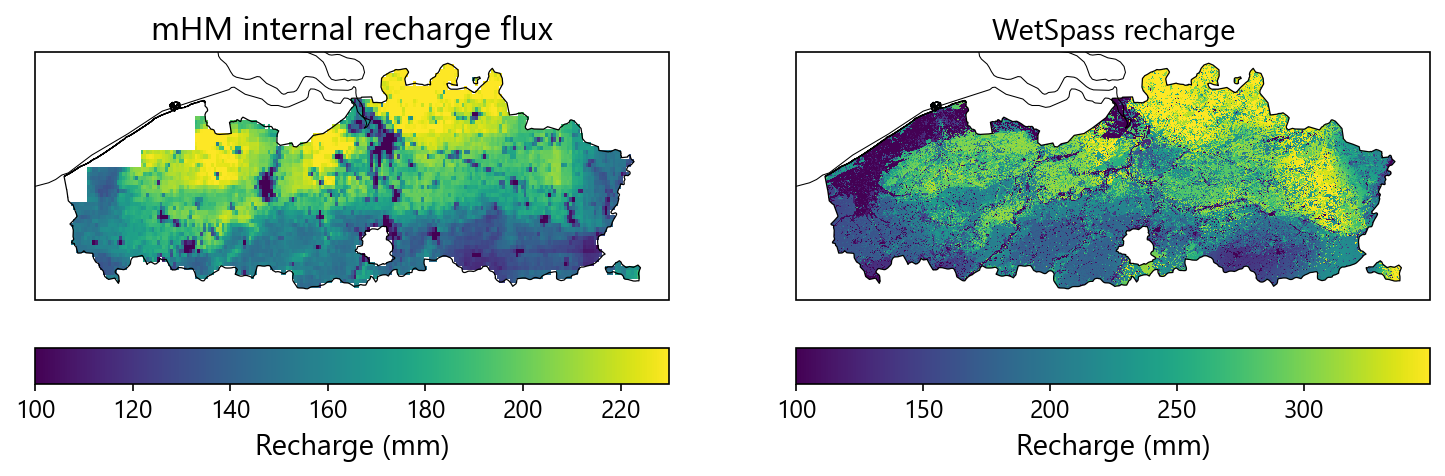

(<Figure size 1800x1200 with 4 Axes>,
 array([<GeoAxes: title={'center': 'mHM internal recharge flux'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
        <GeoAxes: title={'center': 'WetSpass recharge'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>],
       dtype=object),
 (<matplotlib.colorbar.Colorbar at 0x28393c3b7f0>,
  <matplotlib.colorbar.Colorbar at 0x28393c4b220>))

In [21]:
# ---- Call it with data ----
mhm_da = mhm_EOBS_y["recharge"].where(mhm_EOBS_y["recharge"] > 10)
wet_da = wetspass_nc["recharge"]

plot_recharge_side_by_side(
    mhm_da=mhm_da,
    wet_da=wet_da,
    vl_shp=vl_shp,
    titles=("mHM internal recharge flux", "WetSpass recharge"),
    panel_labels=("", ""),
    cmap="viridis"
)